---
# **MACHINE LEARNING**
---

```text
1. Data Preprocessing
2. Train-Test SPLIT
3. Feature Engineering
4. Imbalance handling
5. Compare models
6. Select a model
7. Train Model
8. Evaluate Model
9. Improve Model
10. Deploy Model
```

<hr>

#### 🧰 INSTALLs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [184]:
# install numpy and pandas if not already installed
#!pip install numpy pandas

# install xgboost if not already installed
#!pip install xgboost

# install shap if not already installed
#!pip install shap

# install imbalanced-learn
#!pip install imbalanced-learn

<hr>

#### 📂 IMPORTs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [185]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

---
## **Data Preprocessing**
---

### **Load & View the data**

In this project, we will be working with Online Shoppers Intention UCI Machine Learning. The data can be found here:

https://www.kaggle.com/datasets/henrysue/online-shoppers-intention/data

Metadata



In [186]:
import pandas as pd

# load the clean dataset
df = pd.read_csv("../data/processed/online_shoppers_intention_01_standard.csv")
print("Dataset loaded successfully. Shape:", df.shape)
display(df.head())

Dataset loaded successfully. Shape: (12330, 18)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [187]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

None

### **Check shape**

In [188]:
print("Shape:", df.shape[0], "rows and", df.shape[1], "columns\n")

Shape: 12330 rows and 18 columns



### **Check data types**

In [189]:
print("Data Types:")
df.dtypes

Data Types:


admin                      int64
admin_duration           float64
info                       int64
info_duration            float64
prod_related               int64
prod_related_duration    float64
bounce_rate              float64
exit_rate                float64
page_value               float64
special_day              float64
month                        str
os                         int64
browser                    int64
region                     int64
traffic_type               int64
visitor_type                 str
weekend                     bool
revenue                     bool
dtype: object

### **Check missing values**

There are multiple strategies to handle missing data
- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

In [190]:
print("Missing Values:")
print(df.isna().sum())
print(df.info())

Missing Values:
admin                    0
admin_duration           0
info                     0
info_duration            0
prod_related             0
prod_related_duration    0
bounce_rate              0
exit_rate                0
page_value               0
special_day              0
month                    0
os                       0
browser                  0
region                   0
traffic_type             0
visitor_type             0
weekend                  0
revenue                  0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_durat

In [191]:
# Loop print unique values of each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique values ({len(unique_vals)}): {unique_vals}\n")


Column: admin
Unique values (27): [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]

Column: admin_duration
Unique values (3335): [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]

Column: info
Unique values (17): [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]

Column: info_duration
Unique values (1258): [  0.   120.    16.   ... 547.75 368.25 211.25]

Column: prod_related
Unique values (311): [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 10

In [192]:
# loop through columns and print sum of nulls for each column
for col in df.columns:
    print(f"Null values in '{col}': [{df[col].isna().sum()}]")

Null values in 'admin': [0]
Null values in 'admin_duration': [0]
Null values in 'info': [0]
Null values in 'info_duration': [0]
Null values in 'prod_related': [0]
Null values in 'prod_related_duration': [0]
Null values in 'bounce_rate': [0]
Null values in 'exit_rate': [0]
Null values in 'page_value': [0]
Null values in 'special_day': [0]
Null values in 'month': [0]
Null values in 'os': [0]
Null values in 'browser': [0]
Null values in 'region': [0]
Null values in 'traffic_type': [0]
Null values in 'visitor_type': [0]
Null values in 'weekend': [0]
Null values in 'revenue': [0]


### **Check duplicates**

In [193]:
# print number of duplicated rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 125


### **Leakage Handling**
**DROP**
- identifier column (Id) and (Name), they are not useful features (high cardinality and not predictive)
- columns that are future information

Data leakage happens when:
- Information from the test set influences training
- Or when a feature contains **future information**
- Or when preprocessing is done **before splitting**

Very important:
- Remove post-event features
- Remove target proxies
- Remove ID-like features
- Check correlation with target
- Drop leakage features  
- Ensure no post-target info (variables) exists
- Fit transformations only on training set

Note:
- This step is more important than imbalance handling
- This step can be done either before or right after the step 2 - train/test split

### **Deal with IDs & Name Columns**

In [194]:
# df = df.drop(["IDs", "Name",...], axis=1)

### **Deal with Nulls & Duplicates**

In [195]:
# remove nulls
# df = df.dropna()

# remove duplicates
# df = df.drop_duplicates()


### **Convert Data TYPE**

In [196]:
# --- Convert Boolean to integer ---
# boolean columns
bool_cols = ["weekend", "revenue"]

# convert booleans to integers (True=1, False=0) for better modeling
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

---
### **CHECK PREPROCESSED DATA**

In [197]:
# display cleaned dataframe
display(df.head())

,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


| Variable                  | Cat vs Num   | Identity | Original Python Type | Action          | Convert to | Definition |
|---------------------------|-------------|----------|----------------------|-----------------|------------|------------|
| `admin`                   | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited by the visitor in the Administrative category |
| `admin_duration`          | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Administrative pages |
| `info`                    | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited in the Informational category |
| `info_duration`           | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Informational pages |
| `prod_related`            | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited in the Product-Related category |
| `prod_related_duration`   | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Product-Related pages |
| `bounce_rate`             | Numerical   | Feature  | float                | Scale           | -          | Average bounce rate of the pages visited (percentage of single-page sessions) |
| `exit_rate`               | Numerical   | Feature  | float                | Scale           | -          | Average exit rate of the pages visited (percentage of exits from those pages) |
| `page_value`              | Numerical   | Feature  | float                | Scale           | -          | Average value of the pages visited before completing a transaction (estimated by Google Analytics) |
| `special_day`             | Numerical   | Feature  | float                | Scale           | -          | Closeness of the visit date to a specific special shopping day (value between 0 and 1) |
| `month`                   | Categorical | Feature  | str                  | One-Hot Encode  | int        | Month of the session (e.g., Feb, Mar, May, Nov, Dec) |
| `os`                      | Categorical | Feature  | int                  | One-Hot Encode  | -          | Operating system of the visitor (encoded categorical identifier) |
| `browser`                 | Categorical | Feature  | int                  | One-Hot Encode  | -          | Web browser used by the visitor (encoded categorical identifier) |
| `region`                  | Categorical | Feature  | int                  | One-Hot Encode  | -          | Geographic region of the visitor (encoded categorical identifier) |
| `traffic_type`            | Categorical | Feature  | int                  | One-Hot Encode  | -          | Traffic source type (encoded categorical identifier) |
| `visitor_type`            | Categorical | Feature  | str                  | One-Hot Encode  | int        | Visitor type (Returning Visitor, New Visitor, or Other) |
| `weekend`                 | Categorical | Feature  | bool                 | -               | int        | Whether the session occurred on a weekend (TRUE/FALSE) |
| `revenue`                 | Categorical | Target   | bool                 | -               | int        | Whether the session ended with a completed transaction (TRUE/FALSE) |

In [198]:
# display info cleaned dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

In [199]:
# loop print unique values for each column
for col in df.columns:
        print(f"['{col}]': {df[col].unique()}")

['admin]': [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
['admin_duration]': [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
['info]': [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
['info_duration]': [  0.   120.    16.   ... 547.75 368.25 211.25]
['prod_related]': [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  85  97 198 181 126 106 101 108 119
  70 122  91 276 100 291 114 172 217 141 133 156 136 180 135 195  99 362
 179 

---
## **Train-Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

### **Define target (y)**

In [200]:
# define target variable
y = df["revenue"]

### **Define features (X)**
```text
X = df.drop("revenue", axis=1)  # features without the target variable "revenue"
y = df["revenue"]               # target variable "revenue"
```

In [201]:
# define features
X = df.drop(["revenue"], axis=1)

### **SPLIT**
Use `random_state=42` , `stratify`

```text
X,                  # features without the target variable "revenue"
y,                  # target variable "revenue"
test_size=0.2,      # 20% test set, 80% train set
stratify=y,         # maintain class balance in splits
random_state=42     # for reproducibility, keep random state as 42
```

In [202]:

#split the data into training and testing sets (stratify by target variable to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#display the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9864, 17)
X_test shape: (2466, 17)
y_train shape: (9864,)
y_test shape: (2466,)


**Check split data**

In [203]:
print(f"Features=(X) and target=(y) separated. \nShapes:\nX =", X.shape, ", y =", y.shape)
print(100*"-")
print(f"Train/Test split completed. \nShapes: \nX_train = {X_train.shape}, y_train = {y_train.shape}, \nX_test = {X_test.shape}, y_test = {y_test.shape}")
print(100*"-")
print("Display X_train:")
display(X_train.head())

Features=(X) and target=(y) separated. 
Shapes:
X = (12330, 17) , y = (12330,)
----------------------------------------------------------------------------------------------------
Train/Test split completed. 
Shapes: 
X_train = (9864, 17), y_train = (9864,), 
X_test = (2466, 17), y_test = (2466,)
----------------------------------------------------------------------------------------------------
Display X_train:


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend
4263,8,732.25,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,May,3,3,3,2,Returning_Visitor,0
5905,0,0.00,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,Oct,1,8,3,1,Returning_Visitor,1
9434,0,0.00,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,Dec,2,10,1,2,Returning_Visitor,0
3505,2,338.00,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,May,3,2,2,2,Returning_Visitor,0
2067,0,0.00,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,Mar,2,2,7,2,Returning_Visitor,0


---
## **Feautres Engineering**

Steps to Features Engineering:

1. Identify Categorical vs Numerical Features

2. Encode Categorical Features & Scale Numerical Features
- Categorical Features:
    - Hot-one encoding for seperate categories
    - Labeling for ordinal variables
- Numerical Features:
    - Scaling because models can be sensitive to big numbers

3. Convert Target to numeric python type int (False=0; True=1) //Can also be done in the data prep
4. Convert all Features to numeric python type int or float //Can also be done in the data prep
5. Save `X_train.csv`,`X_test.csv` and `y_train.csv`,`y_test.csv`

### **1. Identify Categorical vs Numerical Features**

In [204]:
# define categorical features
cat_cols = ["month", "os", "browser", "region", "traffic_type", "visitor_type"]
        
# define numerical features
num_cols = [col for col in X.columns if col not in cat_cols]

### **2. Encoding Cat & Scaling Num Features**

**All Models require Encoding Categorical Features** 
- OneHotEncoder (nominal)
- OrdinalEncoder (ordinal)
- Handle unknown categories when Encoding
- Avoid label encoding for nominal variables

**Scaling can be conditional per model:**
- **Models that require Scaling:** 
    - Linear models (Logistic Regression, Ridge, Lasso, ElasticNet)
    - Support Vector Machines (SVM)
    - K-Nearest Neighbors (KNN)
    - Neural Networks
    - K-Means / distance-based algorithms

- **Models that DON'T require Scaling:** 
    - Tree-based models (Decision Trees, Random Forest, XGBoost, LightGBM, CatBoost)



In [205]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

# ---- One-Hot Encode ----
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# categorical features in X_train
X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
# categorical features in X_test
X_test_cat = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

# ---- Scale Numerical ----
# scaler = StandardScaler()
# StandardScaler scales numerical features to have mean=0 and std=1

scaler = RobustScaler()
# RobustScaler scales numerical features using median and IQR, making it more robust to outliers

# numerical features in X_train
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

# numerical features in X_test
X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# ---- Replace original X_train and X_test ----
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

# display the shapes of the resulting sets
print("X_train shape after encoding and scaling:", X_train.shape)
display(X_train.head())
print("X_test shape after encoding and scaling:", X_test.shape)
display(X_test.head())

print("y_train shape:", y_train.shape)
display(y_train.head())
print("y_test shape:", y_test.shape)
display(y_test.head())

# ---- Save preprocessed data to CSV files ----
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


X_train shape after encoding and scaling: (9864, 74)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,weekend,month_Aug,month_Dec,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,os_1,os_2,os_3,os_4,os_5,os_6,os_7,os_8,browser_1,browser_2,browser_3,browser_4,browser_5,browser_6,browser_7,browser_8,browser_9,browser_10,browser_11,browser_12,browser_13,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,traffic_type_1,traffic_type_2,traffic_type_3,traffic_type_4,traffic_type_5,traffic_type_6,traffic_type_7,traffic_type_8,traffic_type_9,traffic_type_10,traffic_type_11,traffic_type_12,traffic_type_13,traffic_type_14,traffic_type_15,traffic_type_16,traffic_type_17,traffic_type_18,traffic_type_19,traffic_type_20,visitor_type_New_Visitor,visitor_type_Other,visitor_type_Returning_Visitor
4263,1.75,7.787634,0.0,0.0,0.516129,0.576821,0.118156,-0.331892,12.274195,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5905,-0.25,-0.086022,0.0,0.0,-0.451613,-0.343155,2.159687,2.094534,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9434,-0.25,-0.086022,0.0,0.0,-0.451613,-0.432323,-0.182069,0.694534,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3505,0.25,3.548387,0.0,0.0,-0.032258,0.468310,0.549730,0.344534,19.236250,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2067,-0.25,-0.086022,0.0,0.0,0.451613,0.175789,-0.182069,-0.689044,54.676348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


X_test shape after encoding and scaling: (2466, 74)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,weekend,month_Aug,month_Dec,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,os_1,os_2,os_3,os_4,os_5,os_6,os_7,os_8,browser_1,browser_2,browser_3,browser_4,browser_5,browser_6,browser_7,browser_8,browser_9,browser_10,browser_11,browser_12,browser_13,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,traffic_type_1,traffic_type_2,traffic_type_3,traffic_type_4,traffic_type_5,traffic_type_6,traffic_type_7,traffic_type_8,traffic_type_9,traffic_type_10,traffic_type_11,traffic_type_12,traffic_type_13,traffic_type_14,traffic_type_15,traffic_type_16,traffic_type_17,traffic_type_18,traffic_type_19,traffic_type_20,visitor_type_New_Visitor,visitor_type_Other,visitor_type_Returning_Visitor
4722,0.00,-0.043011,0.0,0.0,-0.161290,-0.340085,1.259012,1.017611,0.000000,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6835,0.00,0.163441,0.0,0.0,0.161290,-0.240364,-0.182069,0.227867,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5524,-0.25,-0.086022,0.0,0.0,-0.387097,-0.391300,1.490614,0.094534,86.336233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
663,-0.25,-0.086022,0.0,0.0,-0.516129,-0.451674,-0.182069,2.094534,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
136,-0.25,-0.086022,0.0,0.0,-0.290323,-0.229786,0.143175,0.590830,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


y_train shape: (9864,)


4263    0
5905    0
9434    0
3505    1
2067    1
Name: revenue, dtype: int32

y_test shape: (2466,)


4722    0
6835    0
5524    1
663     0
136     0
Name: revenue, dtype: int32

In [206]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 9864 entries, 4263 to 11430
Data columns (total 74 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   admin                           9864 non-null   float64
 1   admin_duration                  9864 non-null   float64
 2   info                            9864 non-null   float64
 3   info_duration                   9864 non-null   float64
 4   prod_related                    9864 non-null   float64
 5   prod_related_duration           9864 non-null   float64
 6   bounce_rate                     9864 non-null   float64
 7   exit_rate                       9864 non-null   float64
 8   page_value                      9864 non-null   float64
 9   special_day                     9864 non-null   float64
 10  weekend                         9864 non-null   float64
 11  month_Aug                       9864 non-null   float64
 12  month_Dec                       9864 non-null 

---
## **Imbalance handling**

**Target distribution**, Class balance percentages:
- Class True  = 1 :  /  ≈ 15%
- Class False = 0 :  /  ≈ 85%

imbalanced = 15/85%

Baseline Model
1️⃣ Train Model with scale_pos_weight
2️⃣ Hyperparameter tuning (Cross Validation)
3️⃣ Freeze best model, what does this mean?
4️⃣ Tune decision threshold
5️⃣ Final evaluation on test set

#### Option A — Use Class Weights (Most Standard & Clean) 

In [207]:
# class_weight='balanced'
# class_weight = ?

#### Option B — Resampling (Use Carefully)

#### Option C — Threshold Tuning (Often Overlooked) 

---
# **SELECT MODEL (XGBoost)**

XGBoost has a built-in way to handle class imbalance using the scale_pos_weight parameter.

**Why use it:**
- State-of-the-art for structured/tabular data
- Handles imbalance well
- Often best performer

**Tune:**
- `learning_rate`
- `n_estimators`
- `max_depth`
- `scale_pos_weight` (important for imbalance)

---

### **Load Train/Test CSVs**

In [208]:
import pandas as pd
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")   
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

**SANITY CHECK**

In [209]:
# sanity check - check class distribution in target variable
print("Train sets shapes:", X_train.shape, y_train.shape)
print("Train class distribution:")
print(y_train.value_counts(), y_train.value_counts(normalize=True).round(2))
print(100*"-")
print("Test set shapes:", X_test.shape, y_test.shape)
print("Test class distribution:")
print(y_test.value_counts(), y_test.value_counts(normalize=True).round(2))

Train sets shapes: (9864, 74) (9864, 1)
Train class distribution:
revenue
False      8338
True       1526
Name: count, dtype: int64 revenue
False      0.85
True       0.15
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Test set shapes: (2466, 74) (2466, 1)
Test class distribution:
revenue
False      2084
True        382
Name: count, dtype: int64 revenue
False      0.85
True       0.15
Name: proportion, dtype: float64


**IMPORTs**

In [210]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_recall_curve
)
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

### **Define Model (Baseline)**

In [211]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)
from xgboost import XGBClassifier


# define Baseline - XGBoost model
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

### **Train Model**

**Purpose** →  Train the selected algorithm on the training data to learn patterns and relationships between features and the target variable. 

In [212]:
# fit the model to the training data
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### **Evaluate Model**

Evaluate the XGBOOST model on the test data.

**Metrics:**
- `Accuracy`  this metric is not reliable
- **Classification Report:** False/True : `Precision`, `Recall`, `F1 score`, `Support`
- **AUC:** `PR AUC` and `ROC AUC`
- **Confusion Matrix:** `FP` , `TP` , `TN` , `FN`
- **Cross validation:** `cv mean`, `cv std`, `MCC`.

**NOTES:**
- Use ROC-AUC for overall ranking assessment, 
- but rely on PR-AUC, F1 score, MCC, and threshold-based confusion matrix analysis to make decisions in imbalanced settings. 
- Avoid depending solely on accuracy.

Confusion Matrix:
 [[1999   85]
 [ 155  227]]

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466

ROC-AUC: 0.9301622433700796
PR-AUC: 0.7469250488215831


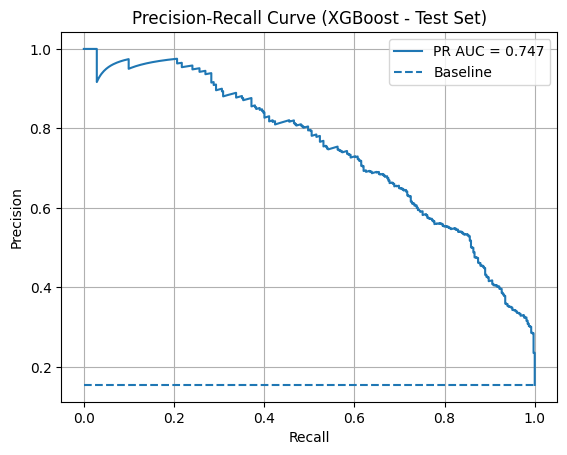

In [213]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# prediction and probability
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))


# ---- PLOT PR CURVE ----
# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# PR AUC
pr_auc = average_precision_score(y_test, y_prob)

# Baseline
baseline = y_test.mean()

# Reset to matplotlib defaults
plt.rcdefaults()

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost - Test Set)")
plt.legend()
plt.grid()
plt.show()

---
### **Check over/under-fitting**

**Method 1: Compare Train vs Test AUC (more reliable than accuracy)**
- **Good generalization**  Small difference → model generalizes well.
- **OVERFITTING:** 
    - Large gap → model memorized training data. 
    - Rule of Thumb → If(Train − Test > 5–7%) probably overfitting.
- **UNDERFITTING:** Both low → model too simple.

In [214]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

# AUC scores
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Difference: {train_auc - test_auc:.4f}")

Train AUC: 0.9472
Test AUC:  0.9302
Difference: 0.0170


**Method 2: CROSS VALIDATION (CV Score)**

If I deploy this model, how stable and reliable will it be on new data?
- If CV score ≈ test score → good.
- If CV score much lower than train → overfitting.

In [215]:
from sklearn.model_selection import StratifiedKFold, cross_validate, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Stratified K-Fold for classification
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Cross-validation with train + validation scores
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

# Extract AUC scores
train_auc = cv_results["train_score"]
val_auc = cv_results["test_score"]

print("Train AUC per fold:", np.round(train_auc, 4))
print("Validation AUC per fold:", np.round(val_auc, 4))

print("\nMean Train AUC:", round(train_auc.mean(), 4))
print("Mean Validation AUC:", round(val_auc.mean(), 4))
print("Validation AUC Std:", round(val_auc.std(), 4))

Train AUC per fold: [0.95   0.9501 0.9502 0.9475 0.9495 0.9503 0.9487 0.9492 0.9487 0.9499]
Validation AUC per fold: [0.9288 0.9319 0.9275 0.9383 0.935  0.9249 0.9361 0.9368 0.9328 0.9339]

Mean Train AUC: 0.9494
Mean Validation AUC: 0.9326
Validation AUC Std: 0.0041


---
# **IMPROVE MODEL**
**Purpose** → Optimize model performance and improve generalization by refining model settings and feature selection.

---
### 📈 **Feature Importance Analysis**

For XGBoost, Use SHAP instead of only feature_importances_ because it gives:
- Global effects by feature
- Local explanation for individual predictions
- Helpful for understanding why the model predicts “True” or “False”.

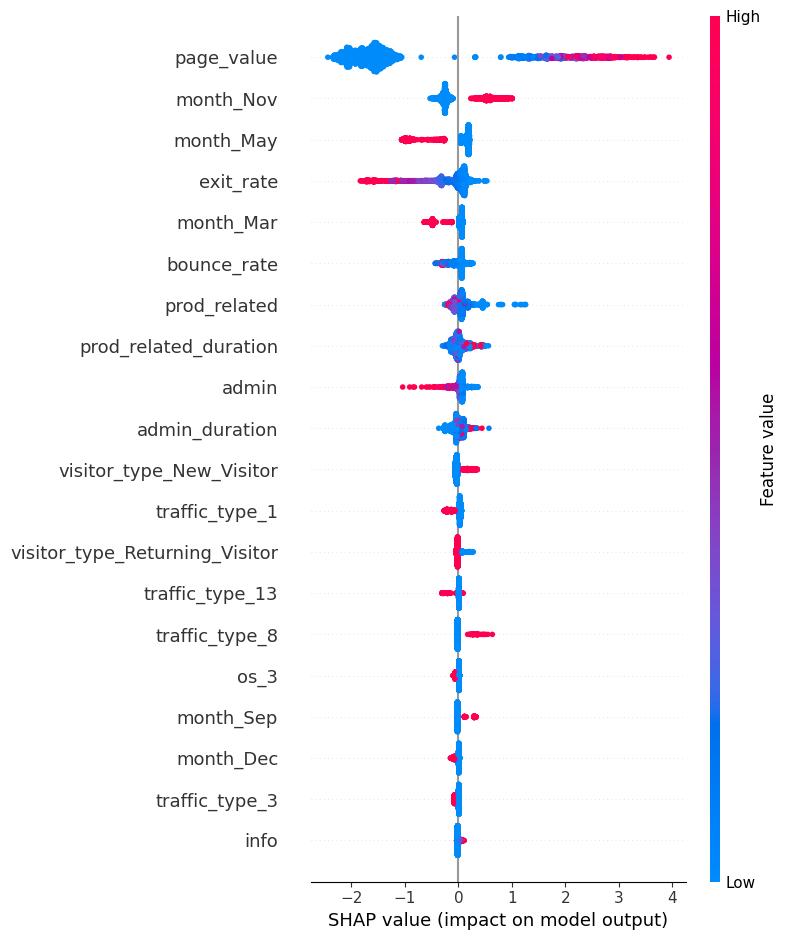

In [216]:
import shap

X_train = X_train.astype(float)
X_test = X_test.astype(float)

explainer = shap.TreeExplainer(model) # Create SHAP explainer
shap_values = explainer.shap_values(X_test) # Calculate SHAP values for the test set
shap.summary_plot(shap_values, X_test) # Plot SHAP summary plot

#### **Feature Selection**

⚖ Important Note About feature_importances_

Limitations:

- Global only
- No direction (positive or negative impact)
- Biased toward high-cardinality features
- Less reliable than SHAP for deep analysis

But perfectly fine for:
- Quick analysis
- Feature selection
- Demo apps

                           feature  importance
8                       page_value    0.383623
18                       month_Nov    0.062454
6                      bounce_rate    0.058139
17                       month_May    0.047943
16                       month_Mar    0.046256
23  visitor_type_Returning_Visitor    0.038686
20                       month_Sep    0.025599
4                     prod_related    0.024697
0                            admin    0.022210
7                        exit_rate    0.021233


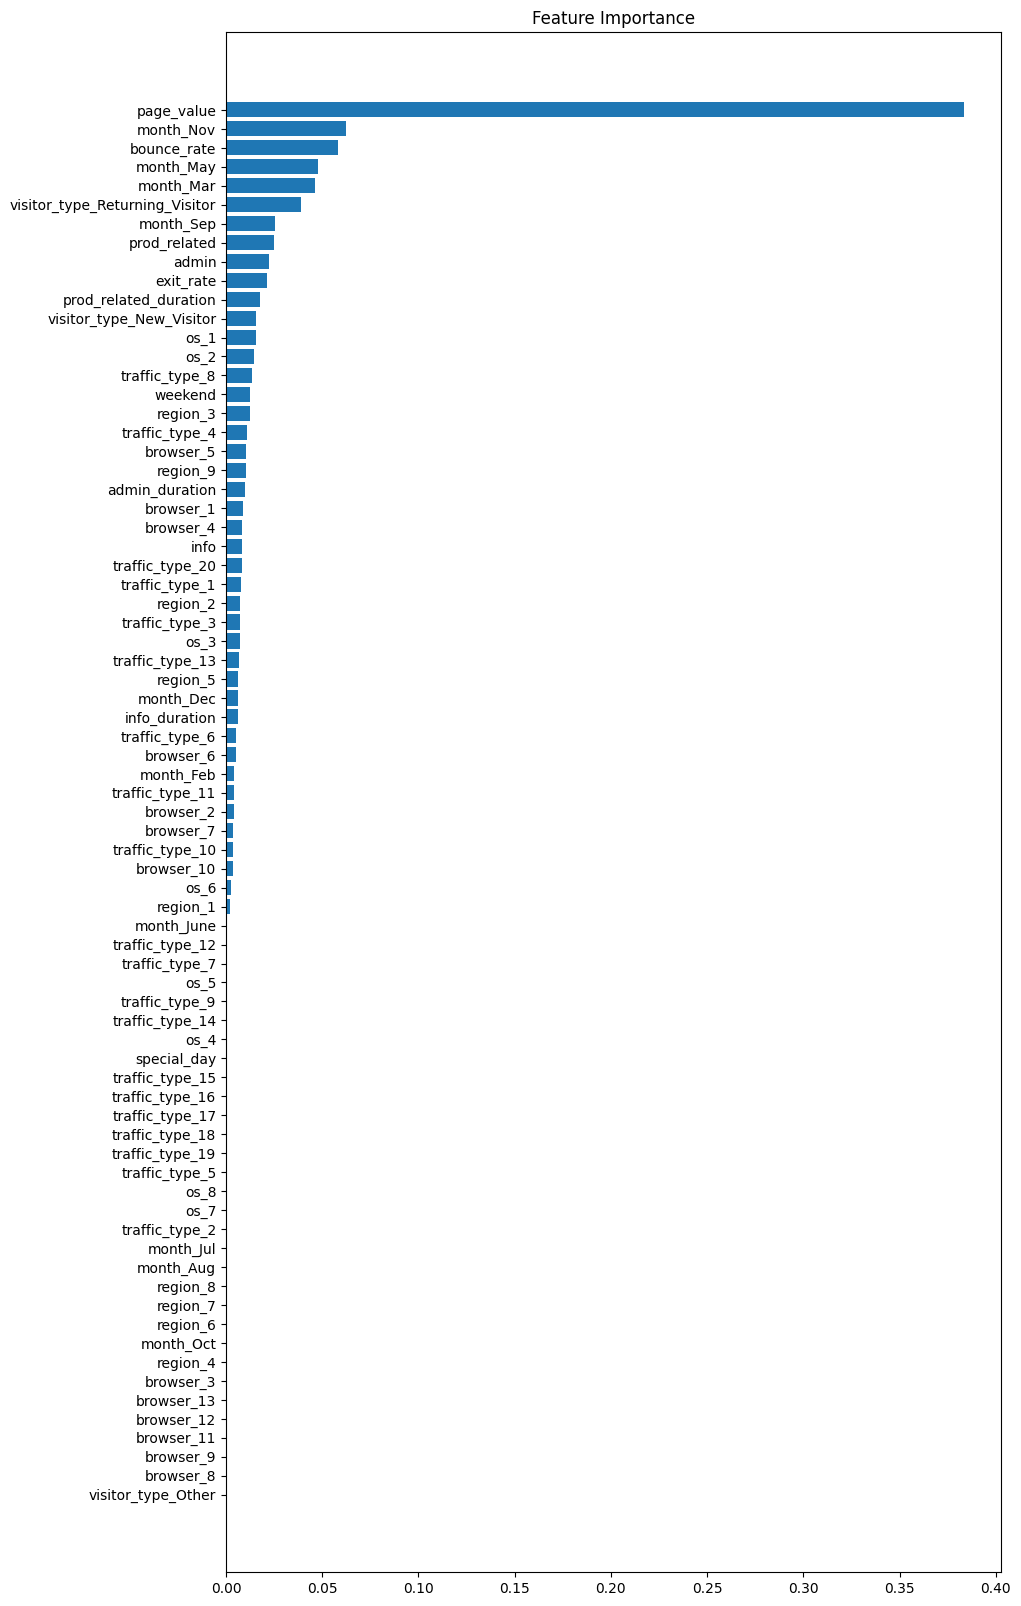

In [222]:
# Get importance
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

# Sort descending
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# print top 10 features
print(feat_imp.head(10))


# PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10,20))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

---
## 🔻 **Reducing overfitting or underfitting**
To reduce overfitting in XGBoost, you need to control model complexity and improve generalization — not just tweak one parameter.

---
## ⚙️ **TUNE Parameters using `RandomizedSearchCV`**
- `learning_rate`
- `n_estimators`
- `max_depth`
- `scale_pos_weight` (important for imbalance)


In [218]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,      # instead of 270 fits
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)

C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best Parameters: {'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV AUC: 0.9341467760308804


####  **Grid Search for Tuning**

In [219]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# calculate scale_pos_weight for imbalanced classes
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# Parameter grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "scale_pos_weight": [1, scale_pos_weight]
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


PicklingError: Could not pickle the task to send it to the workers.

#### **TUNING PARAMETRES**

In [ ]:
# fit the model to the training data
model.fit(X_train, y_train)

---
### ⚙️ **SCALE_POS_WEIGHT**

#### **Calculate scale_pos_weight (class imbalanced)**

The scale_pos_weight tells XGBoost: 

**Misclassifying a positive sample is ~5.46 worse than misclassifying a negative.**

Usually better than oversampling/SMOTE for tree models.

- Negatives = 10422 ; Positives = 1908
- scale_pos_weight = Negatives/Positives = 10422/1908 ≈ 5.46


In [ ]:
import numpy as np
negatives = np.sum(y_train == 0) # same as: negatives = (y_train == 0).sum()
positives = np.sum(y_train == 1) # same as: positives = (y_train == 1).sum()
scale_pos_weight = negatives / positives # Calculate class imbalance ratio
print("scale_pos_weight:", scale_pos_weight) # Print the calculated scale_pos_weight value

#### **scale_pos_weight: Train modified Model - Results - Plot**
Compare these results to previous results.

In [ ]:
# import
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# define XGBoost model - add scale_pos_weight
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,  # added scale_pos_weight to handle class imbalance
    eval_metric='aucpr',                # use AUC-PR as evaluation metric for early stopping, recommended for imbalance
    random_state=42
)

# TRAIN MODEL: fit the model to the training data
model.fit(X_train, y_train)

# --- Evaluate Model ---

# predictions and probabilities on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("MCC:", matthews_corrcoef(y_test, y_pred))

# Plot Precision-Recall Curve


# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# PR AUC
pr_auc = average_precision_score(y_test, y_prob)

# Baseline
baseline = y_test.mean()

# Reset to matplotlib defaults
plt.rcdefaults()

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost - Test Set)")
plt.legend()
plt.grid()
plt.show()

---
## ⚖️ **ADJUST Decision Threshold**

- Default threshold = 0.5 which is almost never optimal in imbalanced problems.

Instead of default 0.5 , Choose threshold based on:
- ROC curve
- Precision-Recall curve
- Business cost matrix

Especially important if:
- Imbalanced dataset
- High recall required
- Fraud / medical / churn ...

**Use validation set to choose threshold that balances precision and recall.**

In [ ]:
# Predictions
# standard threshold of 0.5
#y_pred = model.predict(X_test)
#y_prob = model.predict_proba(X_test)[:, 1]

# custom threshold of 0.37
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.37).astype(int)

---
## 📝**EVALUATE REPEAT**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    average_precision_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix
)
import xgboost



print(100*"-")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)
print(100*"-")

# Classification Report
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))
print(100*"-")

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_prob)
print("XGBoost PR AUC:", pr_auc)

# ROC AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("XGBoost ROC AUC:", roc_auc)
print(100*"-")


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("XGBoost Confusion Matrix:\n", conf_matrix)
print(100*"-")

# MCC
mcc = matthews_corrcoef(y_test, y_pred)
print("MCC:", mcc)
print(100*"-")
# check overfitting or underfitting by comparing train and test performance
# comparing Train vs Test performance
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print(100*"-")


# --- Evaluate Model ---

# predictions and probabilities on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("MCC:", matthews_corrcoef(y_test, y_pred))

# ---- Plot Precision-Recall Curve ----

# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# PR AUC
pr_auc = average_precision_score(y_test, y_prob)

# Baseline
baseline = y_test.mean()

# Reset to matplotlib defaults
plt.rcdefaults()

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost - Test Set)")
plt.legend()
plt.grid()
plt.show()

---
# **DEPLOY MODEL**
Using `Streamlit` for an interface for Real Time Prediction

**Model Packaging**

**Deploy pickle**

---
# **NOTES**

👉 Best model by ROC-AUC: XGBoost
- It shows the strongest ability to rank positive cases above negative ones.

⚠️ Is ROC-AUC sufficient for imbalanced data? No!
- ROC-AUC can be misleading in imbalanced datasets because:
    - It evaluates performance across all thresholds.
    - It gives equal weight to TPR and FPR.
    - With many more negatives than positives, FPR can appear artificially low, inflating the ROC-AUC score.
    - A high ROC-AUC does not guarantee good detection of the minority class.


📊 Recommended metrics:
- ✅ PR-AUC
- ✅ Precision & Recall
- ✅ F1-score / F2-score
- ❌ Do not rely solely on accuracy


🔎 For imbalanced datasets, prioritize:
- 1️⃣ PR-AUC ⭐
    - More informative when the positive class is rare.
    - Focuses on positive class performance.

- 2️⃣ F1-score
    - Balances precision and recall.

- 3️⃣ Recall (Sensitivity)
    - Critical when missing positives is costly.

- 4️⃣ Confusion Matrix
    - Shows actual classification outcomes at the selected threshold.

